# Symbolic Computation with SymPy: solution set

Complete code for every step of the four activity problems in `sympy_intro.ipynb`. Try each step yourself first.

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math
sp.init_printing()

---
## Problem 1: symbols, functions and printing

**Goal:** build expressions with the right assumptions, write a Python function that builds an expression for you, and print the result in three ways.

**What you will see:** the *same* formula simplifies differently depending on what SymPy knows about the symbols, and one expression has several printed forms.

In [2]:
x = sp.Symbol('x', real=True)
t = sp.Symbol('t', positive=True)

### Step 1: assumptions and simplification

In [3]:
E1 = sp.sqrt(t**2) * (x**2 - 1) / (x - 1)
E2 = sp.sqrt(x**2)
E1_simple = sp.simplify(E1)
E2_simple = sp.simplify(E2)
display(E1_simple, E2_simple)

### Step 2: a function that builds expressions

In [4]:
def make_poly(coeffs, var):
    result = 0
    for i in range(len(coeffs)):
        result = result + coeffs[i] * var**i
    return result

### Step 3: three ways to print

In [5]:
P = make_poly([1, -3, 0, 2], x)
print(P)
sp.pprint(P)
P_tex = sp.latex(P)
print(P_tex)
display(Math("P(x) = " + P_tex))
display(sp.Eq(sp.Derivative(P, x), sp.diff(P, x)))
P_eq = sp.latex(sp.Eq(sp.Function('P')(x), P), mode='equation')
print(P_eq)

2*x**3 - 3*x + 1
   3          
2⋅x  - 3⋅x + 1
2 x^{3} - 3 x + 1


<IPython.core.display.Math object>

\begin{equation}P{\left(x \right)} = 2 x^{3} - 3 x + 1\end{equation}

---
## Problem 2: roots and derivatives

**Goal:** find and classify the critical points of

$$f(x) = x^3 - 6x^2 + 9x + 1,$$

find its real root, solve an equation that has **no** formula, and find the minimum of a function of two variables.

**What you will see:** `solve` is perfect for $f'(x) = 0$, but returns an unreadable formula for $f(x) = 0$; `nsolve` gives the number directly.

In [6]:
x, y = sp.symbols('x y', real=True)
f2 = x**3 - 6*x**2 + 9*x + 1

### Step 1: critical points and the second derivative test

In [7]:
fp2 = sp.diff(f2, x)
fpp2 = sp.diff(f2, x, 2)
crit2 = sorted(sp.solve(fp2, x))
kinds2 = []
for c in crit2:
    if fpp2.subs(x, c) < 0:
        kinds2.append("max")
    else:
        kinds2.append("min")
    print(f"x = {c}:  f = {f2.subs(x, c)},  f'' = {fpp2.subs(x, c)}  ->  {kinds2[-1]}")

x = 1:  f = 5,  f'' = -6  ->  max
x = 3:  f = 1,  f'' = 6  ->  min


### Step 2: exact or numeric roots?

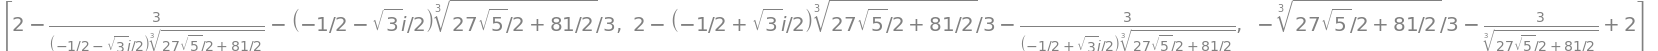

f(0) = 1   f(-1) = -15
root2 = -0.103803402735537    real_roots: -0.103803402735537
r_cos = 0.739085133215161


In [8]:
display(sp.solve(f2, x))
print("f(0) =", f2.subs(x, 0), "  f(-1) =", f2.subs(x, -1))
root2 = sp.nsolve(f2, x, 0)
r_cos = sp.nsolve(sp.cos(x) - x, x, 1)
print("root2 =", root2, "   real_roots:", sp.real_roots(f2)[0].evalf())
print("r_cos =", r_cos)

### Step 3: two variables

In [9]:
F_xy = x**2 + x*y + y**2 - 3*x
grad = [sp.diff(F_xy, x), sp.diff(F_xy, y)]
crit_xy = sp.solve(grad, [x, y])
H = sp.hessian(F_xy, (x, y))
display(grad, crit_xy, H, H.eigenvals())

⎡2  1⎤
⎢    ⎥
⎣1  2⎦

---
## Problem 3: linear algebra

**Goal:** analyse a singular matrix with RREF, rank and null space; diagonalize a matrix with a repeated eigenvalue and compute $A^n$ for symbolic $n$; and see the difference between the matrix product and the elementwise product.

$$B = \begin{pmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & 8 & 9 \end{pmatrix}, \qquad A = \begin{pmatrix} 4 & 1 & -1 \\ 2 & 5 & -2 \\ 1 & 1 & 2 \end{pmatrix}$$

In [10]:
B3 = sp.Matrix([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
A3 = sp.Matrix([[4, 1, -1], [2, 5, -2], [1, 1, 2]])
n = sp.Symbol('n', integer=True, nonnegative=True)

### Step 1: RREF, rank, determinant, null space of $B$

In [11]:
R3, piv3 = B3.rref()
rank3 = B3.rank()
det3 = B3.det()
null3 = B3.nullspace()
display(R3, piv3, rank3, det3, null3)
for v in null3:
    display(B3 @ v)

⎡1  0  -1⎤
⎢        ⎥
⎢0  1  2 ⎥
⎢        ⎥
⎣0  0  0 ⎦

⎡⎡1 ⎤⎤
⎢⎢  ⎥⎥
⎢⎢-2⎥⎥
⎢⎢  ⎥⎥
⎣⎣1 ⎦⎦

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

### Step 2: diagonalization, matrix powers and elementwise products

In [12]:
P3, D3 = A3.diagonalize()
display(P3, D3)
print("A = P D P^-1:", P3 @ D3 @ P3.inv() == A3)
An3 = sp.simplify(P3 @ D3**n @ P3.inv())
display(An3)
print("n = 5 matches A**5:", An3.subs(n, 5) == A3**5)
prod3 = A3 @ A3
hadamard3 = A3.multiply_elementwise(A3)
display(prod3, hadamard3)

⎡-1  1  1⎤
⎢        ⎥
⎢1   0  2⎥
⎢        ⎥
⎣0   1  1⎦

⎡3  0  0⎤
⎢       ⎥
⎢0  3  0⎥
⎢       ⎥
⎣0  0  5⎦

A = P D P^-1: True


⎡  n    n      n    n    n    n ⎤
⎢ 3    5      3    5    3    5  ⎥
⎢ ── + ──   - ── + ──   ── - ── ⎥
⎢ 2    2      2    2    2    2  ⎥
⎢                               ⎥
⎢   n    n      n        n    n ⎥
⎢- 3  + 5      5        3  - 5  ⎥
⎢                               ⎥
⎢   n    n     n    n     n    n⎥
⎢  3    5     3    5   3⋅3    5 ⎥
⎢- ── + ──  - ── + ──  ──── - ──⎥
⎣  2    2     2    2    2     2 ⎦

n = 5 matches A**5: True


⎡17  8   -8 ⎤
⎢           ⎥
⎢16  25  -16⎥
⎢           ⎥
⎣8   8    1 ⎦

⎡16  1   1⎤
⎢         ⎥
⎢4   25  4⎥
⎢         ⎥
⎣1   1   4⎦

---
## Problem 4: integrals, NumPy and plotting

**Goal:** analyse and plot

$$h(x) = (x^2 - 4)\,e^{-x/3} \qquad \text{on } [-3, 12],$$

using **only** symbolic results for every special point, line and number in the figure, and check an exact integral against a numerical one.

**What you will see:** with SymPy doing the algebra, the roots, the critical points, the tangent line and the areas all come out **exact**; `lambdify` turns them into NumPy functions for numerics and plotting.

In [13]:
x = sp.Symbol('x', real=True)
h4 = (x**2 - 4) * sp.exp(-x / 3)

### Step 1: the symbolic part

check antiderivative: 0


array([-0.60555128,  6.60555128])

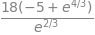

float(area4) = -11.148327973949117


In [14]:
hp4 = sp.diff(h4, x)
roots4 = sorted(sp.solve(h4, x))
crit4 = sorted(sp.solve(hp4, x), key=float)
tangent4 = sp.expand(h4.subs(x, 0) + hp4.subs(x, 0) * x)
H4 = sp.integrate(h4, x)
print("check antiderivative:", sp.simplify(sp.diff(H4, x) - h4))
area4 = sp.simplify(sp.integrate(h4, (x, -2, 2)))
area4_inf = sp.simplify(sp.integrate(h4, (x, -2, sp.oo)))
display(roots4, crit4, np.array(crit4, dtype=float), tangent4, H4, area4, area4_inf)
print("float(area4) =", float(area4))

### Step 2: the trapezoid rule with `lambdify`

In [15]:
def trap(f_np, a, b, N):
    step = (b - a) / N
    total = 0
    for i in np.arange(0, N + 1):
        xi = a + i * step
        if i == 0 or i == N:
            total = total + f_np(xi) / 2
        else:
            total = total + f_np(xi)
    return step * total

h4_np = sp.lambdify(x, h4, 'numpy')
a, b = -2, 2
for N in [10, 20, 40, 80, 160]:
    print(f"N = {N:4d}   error = {abs(trap(h4_np, a, b, N) - float(area4)):.3e}")

N =   10   error = 1.310e-01
N =   20   error = 3.280e-02
N =   40   error = 8.203e-03
N =   80   error = 2.051e-03
N =  160   error = 5.127e-04


### Step 3: the figure

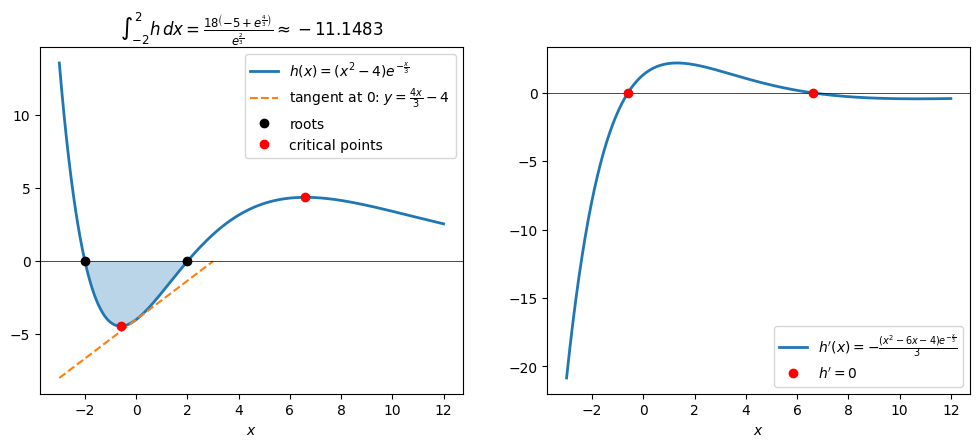

In [16]:
hp_np = sp.lambdify(x, sp.diff(h4, x), 'numpy')
tan_np = sp.lambdify(x, tangent4, 'numpy')
r = np.array(roots4, dtype=float)
c = np.array(crit4, dtype=float)
xs = np.linspace(-3, 12, 500)
xt = np.linspace(-3, 3, 50)
mask = (xs >= -2) & (xs <= 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(xs, h4_np(xs), lw=2, label=f"$h(x) = {sp.latex(h4)}$")
axes[0].plot(xt, tan_np(xt), "--", label=f"tangent at 0: $y = {sp.latex(tangent4)}$")
axes[0].plot(r, h4_np(r), "ko", label="roots")
axes[0].plot(c, h4_np(c), "ro", label="critical points")
axes[0].fill_between(xs[mask], h4_np(xs[mask]), alpha=0.3)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_title(f"$\\int_{{-2}}^{{2}} h\\,dx = {sp.latex(area4)} \\approx {float(area4):.4f}$")
axes[1].plot(xs, hp_np(xs), lw=2, label=f"$h'(x) = {sp.latex(sp.factor(sp.diff(h4, x)))}$")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].plot(c, hp_np(c), "ro", label="$h' = 0$")
for ax in axes:
    ax.set_xlabel("$x$")
    ax.legend()
plt.show()